# 05. Budget Optimization

Allocate a $1M media budget across TV, Google Search, and TikTok over the next 13 weeks to maximize expected media contribution.

For this synthetic example, one spend unit represents $1,000.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

from pymc_marketing.mmm.multidimensional import (
    MMM,
    MultiDimensionalBudgetOptimizerWrapper,
)

root = Path("..")

mmm = MMM.load(root / "artifacts/mmm_regularized_with_ppc.nc")

df = pd.read_csv(
    root / "data/scenario_a/scenario_a_train.csv",
    parse_dates=["date_week"],
)

channels = mmm.channel_columns

names = {
    "tv_spend": "TV",
    "google_search_spend": "Google Search",
    "tiktok_spend": "TikTok",
}

In [9]:
TOTAL_BUDGET = 1_000        # $000s = $1M
CAMPAIGN_WEEKS = 13

last_date = df["date_week"].max()
start_date = last_date + pd.Timedelta(weeks=1)
end_date = start_date + pd.Timedelta(weeks=CAMPAIGN_WEEKS - 1)

optimizer = MultiDimensionalBudgetOptimizerWrapper(
    model=mmm,
    start_date=str(start_date.date()),
    end_date=str(end_date.date()),
)

n_periods = optimizer.num_periods
budget_per_period = TOTAL_BUDGET / n_periods

print("Optimization window:", start_date.date(), "to", end_date.date())
print("Periods:", n_periods)
print("Total budget: $1,000,000")
print(f"Weekly budget: ${budget_per_period * 1000:,.0f}")

Optimization window: 2025-06-30 to 2025-09-22
Periods: 13
Total budget: $1,000,000
Weekly budget: $76,923


In [10]:
recent_mix = (
    df.tail(n_periods)[channels].mean()
    / df.tail(n_periods)[channels].mean().sum()
)

baseline = recent_mix * budget_per_period

budget_bounds = xr.DataArray(
    np.column_stack([
        0.5 * baseline.values,
        1.5 * baseline.values,
    ]),
    dims=["channel", "bound"],
    coords={
        "channel": channels,
        "bound": ["lower", "upper"],
    },
)

optimal_budget, result = optimizer.optimize_budget(
    budget=budget_per_period,
    budget_bounds=budget_bounds,
    minimize_kwargs={
        "method": "SLSQP",
        "options": {"ftol": 1e-4, "maxiter": 10_000},
    },
)

print(result)

/opt/miniconda3/envs/walmart_mmm_312/lib/python3.12/site-packages/pymc_marketing/mmm/budget_optimizer.py:808: UserWarning: Using default equality constraint
  self.set_constraints(


     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -1614.5559558204532
           x: [ 1.912e+01  3.673e+01  2.107e+01]
         nit: 8
         jac: [-1.559e+01 -1.558e+01 -1.558e+01]
        nfev: 8
        njev: 8
 multipliers: [-1.559e+01]


In [12]:
allocation = pd.DataFrame(
    {
        "Current Mix ($)": baseline.values * n_periods * 1000,
        "Optimized ($)": optimal_budget.values * n_periods * 1000,
    },
    index=[names[c] for c in channels],
)

allocation["Current Share"] = (
    allocation["Current Mix ($)"] / 1_000_000
)

allocation["Optimized Share"] = (
    allocation["Optimized ($)"] / 1_000_000
)

allocation.round({
    "Current Mix ($)": 0,
    "Optimized ($)": 0,
    "Current Share": 3,
    "Optimized Share": 3,
})

,Current Mix ($),Optimized ($),Current Share,Optimized Share
TV,258618.0,248562.0,0.259,0.249
Google Search,515056.0,477476.0,0.515,0.477
TikTok,226326.0,273962.0,0.226,0.274


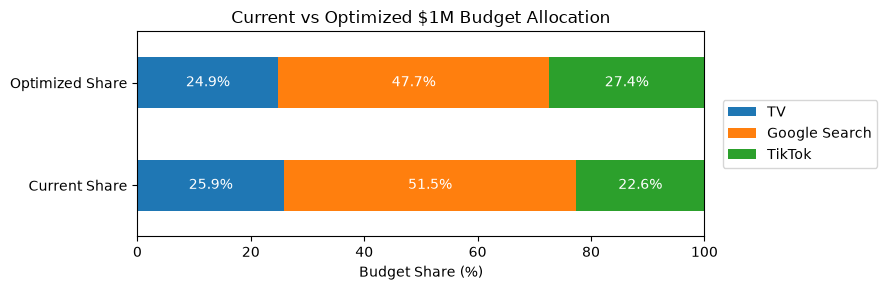

In [16]:
import matplotlib.pyplot as plt

shares = allocation[["Current Share", "Optimized Share"]].T * 100

ax = shares.plot(
    kind="barh",
    stacked=True,
    figsize=(9, 3)
)

ax.set_title("Current vs Optimized $1M Budget Allocation")
ax.set_xlabel("Budget Share (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)

# 把 legend 放到图外右侧
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

# 在每个色块中间标注百分比
for y_idx, row_name in enumerate(shares.index):
    left = 0
    for col in shares.columns:
        value = shares.loc[row_name, col]
        if value >= 5:  # 太小的块就不写，避免挤在一起
            ax.text(
                left + value / 2,
                y_idx,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=10
            )
        left += value

plt.tight_layout()
plt.show()